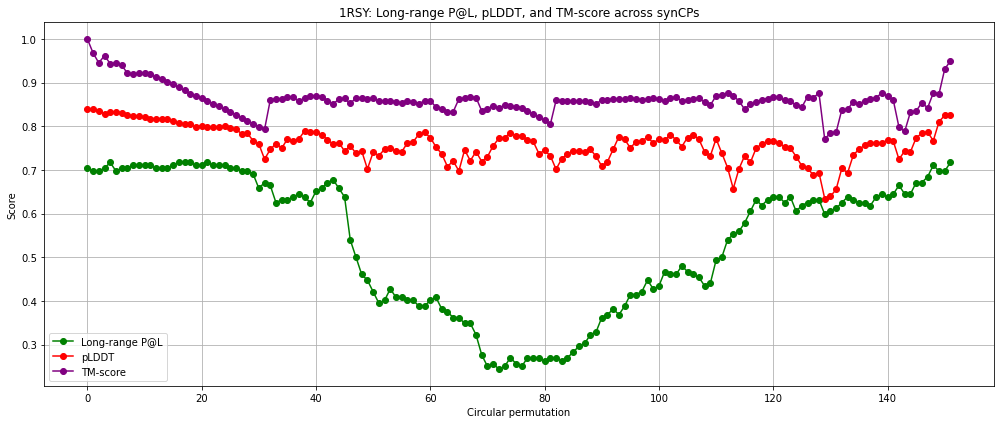

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load TSV
pdb = '1RSY'
tsv_file =  f"{pdb}_CP_contact_precision_tm_score_plddt.tsv"
df = pd.read_csv(tsv_file, sep="\t")

# Strip any whitespace from column names
df.columns = df.columns.str.strip()

# Extract numeric permutation ID
df['id_num'] = df['id'].str.extract(r'cut(\d+)_')[0].astype(int)
df = df.sort_values('id_num')

# Ensure numeric 1D columns
for col in ['long_P@L', 'plddt', 'tm_score']:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')  # convert objects to floats
    df[col] = df[col].values  # make sure it's a plain numpy array

# Plotting
plt.figure(figsize=(14,6))

plt.plot(df['id_num'].values, df['long_P@L'].values, color='green', marker='o', label='Long-range P@L')
plt.plot(df['id_num'].values, df['plddt'].values*.01, color='red', marker='o', label='pLDDT')
plt.plot(df['id_num'].values, df['tm_score'].values, color='purple', marker='o', label='TM-score')

plt.xlabel("Circular permutation")
plt.ylabel("Score")
plt.title(f"{pdb}: Long-range P@L, pLDDT, and TM-score across synCPs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{pdb}_synCP_metrics.png", dpi=300)
plt.show()